# Electrostatic Capacitance Extraction with Palace

We use `gsim.palace.ElectrostaticSim` to extract the **plate-to-plate (mutual)
capacitance** of the IHP `cmim` (MIM capacitor) cell and compare it against the IHP
PDK compact model. The bottom plate is on Metal5
(terminal `T1` = SPICE `MINUS`), the top plate is the MIM top-metal (`mim` layer,
`T2` = `PLUS`). The two plates are separated by the 40 nm high-k MIM dielectric
(`mim_diel`, SiN, εᵧ ≈ 7.5); the MIM top-metal is 150 nm and is
brought out through a 10x10 array of Vmim vias to TopMetal1 for external connection.

Palace writes two matrices: `terminal-C.csv` (Maxwell — self-cap on the diagonal,
negative induced charge off-diagonal) and `terminal-Cm.csv` (mutual/"SPICE" — its
off-diagonal `Cm[i,j] = -C[i,j]` is the physical two-terminal capacitor). The MIM cap
value is `Cm[1,2]`, which is exactly what the PDK `cap_cmim` model describes.

The IHP `cap_cmim` is a 2-terminal model with an area + perimeter law (plate-to-plate
only; substrate parasitics are left to extraction). See
[`capacitors_mod.lib`](https://github.com/IHP-GmbH/IHP-Open-PDK/blob/main/ihp-sg13g2/libs.tech/ngspice/models/capacitors_mod.lib).

**Limitation:** one terminal per layer — multiple electrodes on the same layer (e.g.
interdigitated caps) are not yet supported.

**Requirements:**
- An IHP PDK whose MIM stack carries the split `mim_diel` (dielectric) + `mim`
  (top-metal) layer levels. The pre-fix release lumped both into a single SiO₂
  `mim` level, which cannot model the capacitor (see gdsfactory/IHP#188 and the fix
  in gdsfactory/IHP#225). Install a version containing the fix, e.g.
  `uv pip install "ihp-gdsfactory @ git+https://github.com/gdsfactory/IHP.git"`.
- A Palace backend — either a local `palace` executable (`sim.run_local()`) or a
  [GDSFactory+](https://gdsfactory.com) account for cloud simulation (`sim.run()`).

### Load IHP MIM capacitor

Ports: [('MINUS', (-5.86, 0.0)), ('PLUS', (4.5, 0.0))]


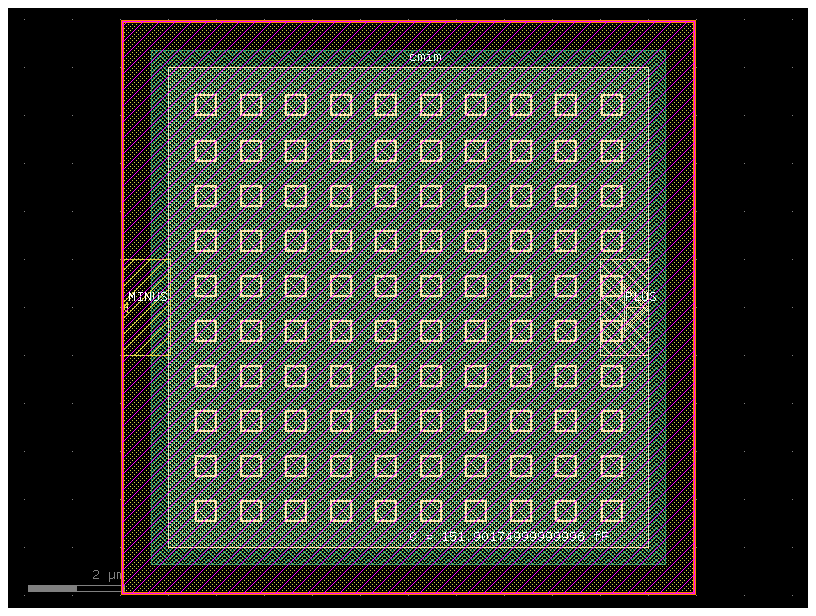

In [1]:
from ihp import PDK, cells

PDK.activate()

cap_width = 10.0  # um
cap_length = 10.0  # um

# IHP cmim: Metal5 (bottom plate, MINUS) -> 40 nm MIM dielectric (mim_diel, SiN)
#   -> 150 nm MIM top-metal (mim layer, the top electrode) -> 10x10 Vmim vias
#   -> TopMetal1 (external connection, PLUS)
c = cells.cmim(width=cap_width, length=cap_length).copy()
print("Ports:", [(p.name, tuple(p.center)) for p in c.ports])

cc = c.copy()
cc.draw_ports()
cc

### Configure ElectrostaticSim

In [2]:
from gsim.palace import ElectrostaticSim

sim = ElectrostaticSim()

sim.set_output_dir("./palace-sim-electrostatic")
sim.set_geometry(c)
sim.set_stack(substrate_thickness=2.0)
sim.set_airbox(margin_x=5, margin_y=5, z_above=5, z_below=5)

# Metal5 = bottom plate (MINUS); the `mim` layer is the MIM top plate (PLUS).
# We measure the device capacitance between these two electrodes, separated by
# the 40 nm mim_diel. TopMetal1 is only the routing metal above the top plate.
sim.add_terminal("T1", layer="metal5")
sim.add_terminal("T2", layer="mim")

sim.set_electrostatic()

print(sim.validate_config())

Validation: PASSED


### Mesh and generate config

In [3]:
# Vmim vias are 0.42 um with 0.52 um gaps; MIM dielectric is 40 nm thick
sim.mesh(preset="fine", refined_mesh_size=0.1, merge_via_distance=0)

# Palace needs a config file to run. `run()` writes it automatically, but the
# local `run_local()` path does not, so write it explicitly after meshing.
sim.write_config()

PosixPath('palace-sim-electrostatic/config.json')

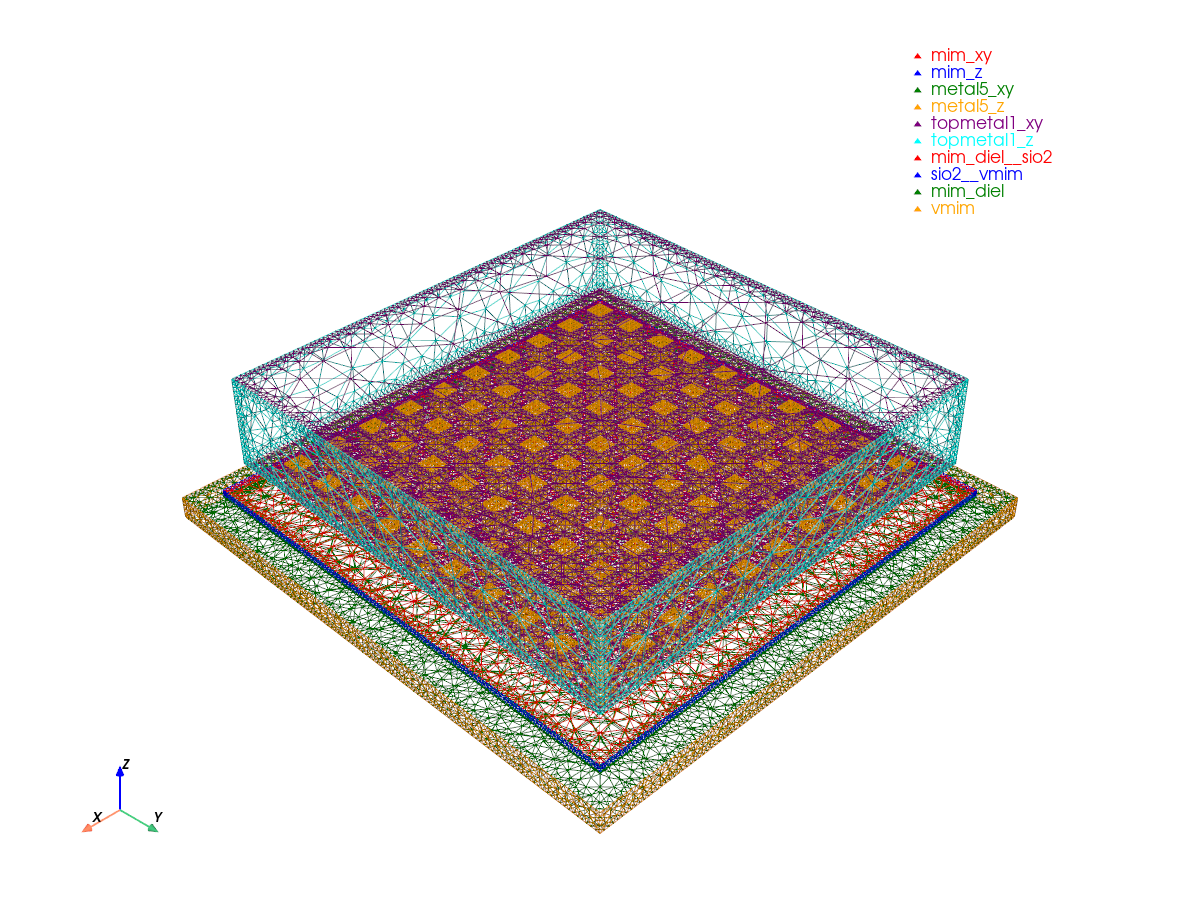

In [4]:
# sim.plot_mesh(show_groups=["metal", "topmetal", "via", "dielectric", "SiO2__vmim"])

sim.plot_mesh(show_groups=["metal5", "mim", "topmetal1", "vmim", "SiO2__vmim"])

# sim.plot_mesh(
#     style="solid",
#     transparent_groups=["air__None", "sio2__None", "air__sio2", "air__passive"],
#     interactive=True,
# )

### IHP PDK compact-model reference

This is the value the IHP `cap_cmim` SPICE device would report for the same
geometry. We evaluate the PDK's own area + perimeter law using the live `TECH`
process constants (`cmim_caspec` [fF/um^2], `cmim_cpspec` [fF/um], `cmim_lwd`
[um]) via the PDK's `CbCapCalc` helper, so the reference is authoritative rather
than hand-tuned. This is the number to compare the Palace mutual capacitance
`Cm[1,2]` against.

In [5]:
# IHP `cap_cmim` compact model: C = caspec*(w+lwd)*(l+lwd) + 2*cpspec*(w+l+2*lwd),
# with the process constants read from the live PDK `TECH` (fF/um^2 and fF/um).
# `CbCapCalc` is the PDK's own area+perimeter evaluator, so the reference is
# authoritative rather than hand-tuned. (The old `ihp.cells2...Numeric` import was
# removed in IHP 2.0.0; `TECH`/`CbCapCalc` is the supported API.)
from ihp.tech import CbCapCalc, TECH

C_pdk = CbCapCalc("C", 0.0, cap_length, cap_width, "cmim")  # fF (total)

# Area + perimeter breakdown (for transparency)
_caspec = TECH.cmim_caspec  # fF/um^2  area-specific capacitance
_cpspec = TECH.cmim_cpspec  # fF/um    perimeter-specific capacitance
_lwd = TECH.cmim_lwd  # um       line-width delta
_leff = cap_length + _lwd
_weff = cap_width + _lwd
C_pdk_area = _caspec * _leff * _weff
C_pdk_perim = 2.0 * (_leff + _weff) * _cpspec

print(f"IHP model 'cap_cmim' for {cap_width} x {cap_length} um cmim:")
print(f"  area term      = {C_pdk_area:7.2f} fF")
print(f"  perimeter term = {C_pdk_perim:7.2f} fF")
print(f"  C_pdk (total)  = {C_pdk:7.2f} fF   <- reference for Palace Cm[1,2]")

IHP model 'cap_cmim' for 10.0 x 10.0 um cmim:
  area term      =  150.30 fF
  perimeter term =    1.60 fF
  C_pdk (total)  =  151.90 fF   <- reference for Palace Cm[1,2]


### Run

Uncomment the cloud variant to submit to GDSFactory+ cloud. The result should be a
capacitance matrix CSV.

In [6]:
# Run locally with a Palace executable (works with the installed PDK/fork):
results = sim.run_local()

# Alternatively, submit to the GDSFactory+ cloud:
# results = sim.run()

Running Palace simulation in palace-sim-electrostatic directly


Command: /home/martin/Desktop/gsim/.venv/lib/python3.12/site-packages/palacetoolkit_palace_cpu/bin/palace -np 4 config.json


Processes: 4


>> /usr/bin/mpirun -n 4 /home/martin/Desktop/gsim/.venv/lib/python3.12/site-packages/palacetoolkit_palace_cpu/bin/palace-x86_64.bin config.json


_____________     _______


...

Disk IO                         117.7M      117.7M        4.4G


--------------------------------------------------------------


Total                             4.5G        4.5G        4.5G


Simulation completed successfully


Results saved to palace-sim-electrostatic/output/palace


### Load and analyze results

In [7]:
import csv
from pathlib import Path

import numpy as np

# `run_local()` returns a dict of file paths, or a PalaceTextResults object
# (with a `.files` mapping) depending on the gsim version.
if isinstance(results, dict):
    terminal_csv = results["terminal-C.csv"]
else:
    terminal_csv = results.files["terminal-C.csv"]
results_dir = Path(terminal_csv).parent


def read_palace_csv(path):
    """Read a Palace output CSV, returning header and data as numpy array."""
    with open(path) as f:
        reader = csv.reader(f)
        header = next(reader)
        data = np.array([[float(x) for x in row] for row in reader])
    return [h.strip() for h in header], data


# Maxwell capacitance matrix (terminal-C.csv): diagonal = self-capacitance,
# off-diagonal = negative induced charge on the grounded neighbor.
header, C_matrix = read_palace_csv(results_dir / "terminal-C.csv")
print("Maxwell capacitance matrix (F):")
print(f"  C[1,1] = {C_matrix[0, 1]:+.4e} F  ({C_matrix[0, 1] * 1e15:+.3f} fF)")
print(f"  C[1,2] = {C_matrix[0, 2]:+.4e} F  ({C_matrix[0, 2] * 1e15:+.3f} fF)")
print(f"  C[2,1] = {C_matrix[1, 1]:+.4e} F  ({C_matrix[1, 1] * 1e15:+.3f} fF)")
print(f"  C[2,2] = {C_matrix[1, 2]:+.4e} F  ({C_matrix[1, 2] * 1e15:+.3f} fF)")

# Mutual (lumped "SPICE") matrix (terminal-Cm.csv): off-diagonal is the physical
# plate-to-plate capacitor. Cm[1,2] is the device capacitance the PDK models.
_, Cm = read_palace_csv(results_dir / "terminal-Cm.csv")
print(f"\nMutual (plate-to-plate) capacitance  Cm[1,2] = {Cm[0, 2] * 1e15:.3f} fF")

# Domain energy
_, E = read_palace_csv(results_dir / "domain-E.csv")
print(
    f"\nStored electric energy: {E[0, 1]:.4e} J (excitation 1), {E[1, 1]:.4e} J (excitation 2)"
)

Maxwell capacitance matrix (F):
  C[1,1] = +1.9512e-13 F  (+195.125 fF)
  C[1,2] = -1.9422e-13 F  (-194.217 fF)
  C[2,1] = -1.9422e-13 F  (-194.217 fF)
  C[2,2] = +2.1527e-13 F  (+215.271 fF)

Mutual (plate-to-plate) capacitance  Cm[1,2] = 194.217 fF

Stored electric energy: 3.6755e-11 J (excitation 1), 4.0549e-11 J (excitation 2)


### Compare: Palace vs IHP PDK model

The Palace plate-to-plate capacitance is `Cm[1,2]` (equivalently `|C[1,2]|`),
compared against the IHP `cap_cmim` compact-model value `C_pdk`.

> **On the residual gap.** We do not treat a Palace-vs-PDK mismatch as expected.
> It is an open investigation point. A key limitation: Palace's *electrostatic*
> solver models terminals as ideal equipotential (Dirichlet) surfaces and does
> **not** apply a surface-conductivity / conductor-thickness boundary condition.
> Palace's surface-conductivity BC (with a `Thickness` and the standard
> `t/2`-per-side thin-sheet convention) is only available to the
> *frequency-domain Maxwell* solvers (driven/transient/eigenmode), not to
> capacitance extraction. So any dependence of the result on plate thickness or
> surface conductivity cannot currently be exercised here; it would require
> solver support (or a different simulation type).
>
> Likely contributors to the residual:
> - the full 3D fringe / perimeter field Palace captures vs. the compact model's
>   area+perimeter fit, and
> - the PDK's effective permittivity (`cmim_caspec = 1.5 fF/um^2` ≈ εᵧ
>   ≈ 6.8) vs. the `sin` value used in the stack (εᵧ ≈ 7.5).
>
> Worth re-checking whether the mesh models the conductor shell/side walls and
> whether a `t/2` placement of each plate surface is appropriate.

In [8]:
# Palace device (mutual) capacitance — the quantity the PDK models.
C_palace = abs(Cm[0, 2])

print(f"Palace mutual Cm[1,2]:      {C_palace * 1e15:.3f} fF")
print(f"IHP PDK model (cap_cmim):   {C_pdk:.3f} fF")
print(f"Ratio Palace/PDK:           {C_palace * 1e15 / C_pdk:.3f}")

Palace mutual Cm[1,2]:      194.217 fF
IHP PDK model (cap_cmim):   151.902 fF
Ratio Palace/PDK:           1.279
